<a href="https://colab.research.google.com/github/pavithrasmv/Mchine-learning/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5109 - loss: 0.7029 - val_accuracy: 0.6687 - val_loss: 0.6612
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7047 - loss: 0.6503 - val_accuracy: 0.8062 - val_loss: 0.6178
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7703 - loss: 0.6038 - val_accuracy: 0.7875 - val_loss: 0.5769
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7781 - loss: 0.5596 - val_accuracy: 0.7750 - val_loss: 0.5400
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7797 - loss: 0.5213 - val_accuracy: 0.7688 - val_loss: 0.5061
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7844 - loss: 0.4883 - val_accuracy: 0.7688 - val_loss: 0.4738
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7969 - loss: 0.4594 - val_accuracy: 0.7812 - val_loss: 0.4447
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7969 - loss: 0.4340 - val_accuracy: 0.8125 - val_loss

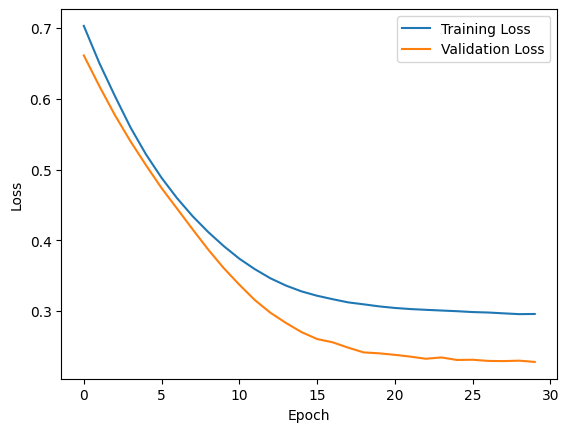

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
np.random.seed(42)
n = 1000
tenure = np.random.randint(1, 73, n)
monthly_bill = np.random.randint(20, 151, n)
support_calls = np.random.randint(0, 8, n)
data_usage = np.random.randint(1, 101, n)
contract_months = np.random.choice([1, 12, 24], n)
risk = (0.025*(monthly_bill-70) - 0.035*tenure
+ 0.45*support_calls - 0.015*data_usage
- 0.05*contract_months + np.random.normal(0,1,n))
churn = (risk > 0.5).astype(int)
df = pd.DataFrame({
"Tenure": tenure, "MonthlyBill": monthly_bill,
"SupportCalls": support_calls, "DataUsage": data_usage,
"ContractMonths": contract_months, "Churn": churn
})
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential([
Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
Dense(8, activation="relu"),
Dense(1, activation="sigmoid")
])


model.compile(optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"])
model.summary()
history = model.fit(
X_train, y_train,
epochs=30, batch_size=32,
validation_split=0.20, verbose=1)
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy)
prob = model.predict(X_test)
pred = (prob >= 0.5).astype(int).ravel()
print(classification_report(y_test, pred))
print("Confusion Matrix:");
print(confusion_matrix(y_test, pred))
# New customer
new_customer = pd.DataFrame({
"Tenure":[8], "MonthlyBill":[120],
"SupportCalls":[6], "DataUsage":[20],
"ContractMonths":[1]
})
new_scaled = scaler.transform(new_customer)
p = model.predict(new_scaled)[0][0]
print("Churn Probability:", p)
print("Prediction:", "May Churn" if p >= 0.5 else "May Stay")
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()